# Representing geographic data as networks

Contents:

- Basic concepts: nodes, edges, node/edge attributes, topology, connectivity, directionality, what Python tools are out there that can be used?
- How to create a simple graph from scratch
- How to create a graph from a file representing streets
- How to create a routable graph from OpenStreetMap
- Other uses of graphs - morphology, spatial weights, etc.
- Saving graphs to disk

## Basic concepts

As we briefly introduced in Chapter 5.2, networks are data structures that consists of nodes that are connected to other nodes via edges which ultimately construct a network (or a graph as it is referred in graph theory). As networks are widely used in various domains, the names used for these basic elements of a network can sometime vary. To clarify some of the ambiguity related to these terms, we list commonly used terms related to spatial networks below:

- `Network` equals to `graph` (term used in graph theory)
- `Node` sometimes equals to `vertex` (term used in graph theory)
- `Edge` (used in graph theory) equals to `line` or `link`, and a `directed edge` can be called as an `arc` in graph theory.

In Python, most of the network analysis related libraries (e.g. `networkx`, `igraph`, `graphtool`) use the terminology derived from the graph theory, i.e. most of the libraries use constructs like `Graph`, `Edge` and `Vertex`. However, `networkx` library which we will mostly cover in this book differs partially as they use a construct `Node` instead of `Vertex`. This makes sense as in GIS there is a difference between these two: A `node` is specific to a point at which a line ends or connects to another line, whereas `vertices` can be in between the `nodes` as intermediate points along the geometry which is typical e.g. when representing road networks. Thus, every `node` of a `graph` can be considered as a `vertex` but not all `vertices` are `nodes`. 




## Creating a simple graph from scratch

### Undirected graph

In this first example, we will construct a simple graph using the `networkx` library and its `nx.Graph()` construct that allows you to create an undirected graph with nodes and edges. 

In [122]:
import networkx as nx
import matplotlib.pyplot as plt
from shapely import Point

G = nx.Graph()
G

In [123]:
G.graph["name"] = "my first graph"
G

In [124]:
G.graph

{'name': 'my first graph'}

In [125]:
a_coords = (0,5)
b_coords = (5,5)
c_coords = (0,0)
d_coords = (5,0)
e_coords = (10,0)

G.add_node("a", coords=a_coords)
G.add_node("b", coords=b_coords)
G.add_node("c", coords=c_coords)
G.add_node("d", coords=d_coords)
G.add_node("e", coords=e_coords)

In [126]:
G.nodes

NodeView(('a', 'b', 'c', 'd', 'e'))

In [127]:
G.nodes.data()

NodeDataView({'a': {'coords': (0, 5)}, 'b': {'coords': (5, 5)}, 'c': {'coords': (0, 0)}, 'd': {'coords': (5, 0)}, 'e': {'coords': (10, 0)}})

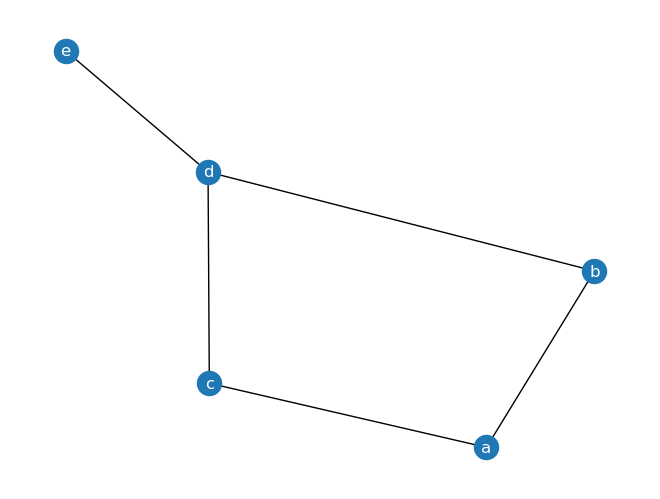

In [139]:
nx.draw(G, with_labels=True, font_color="white")

In [130]:
positions = {node: attrs["coords"] for node, attrs in G.nodes.data()}
positions

{'a': (0, 5), 'b': (5, 5), 'c': (0, 0), 'd': (5, 0), 'e': (10, 0)}

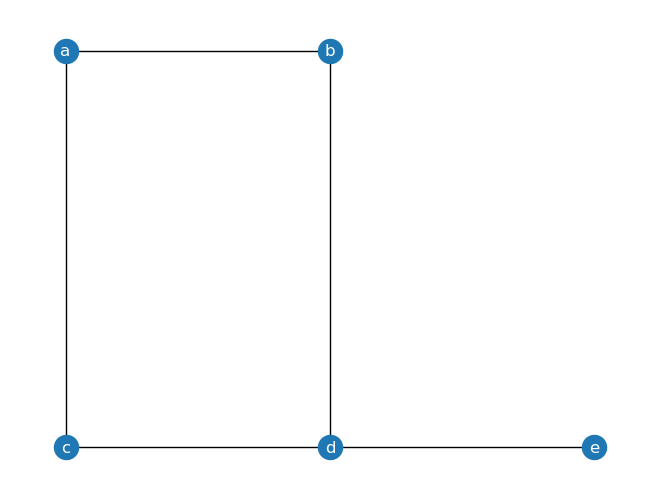

In [137]:
nx.draw(G, with_labels=True, pos=positions, font_color="white")

In [133]:
G.add_edge("a", "b", weight=1)
G.add_edge("a","c", weight=2)
G.add_edge("b","d", weight=1)
G.add_edge("c","d", weight=1)
G.add_edge("d","e", weight=3)

In [134]:
print(G.edges)
print(G.edges.data())

[('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'd'), ('d', 'e')]
[('a', 'b', {'weight': 1}), ('a', 'c', {'weight': 2}), ('b', 'd', {'weight': 1}), ('c', 'd', {'weight': 1}), ('d', 'e', {'weight': 3})]


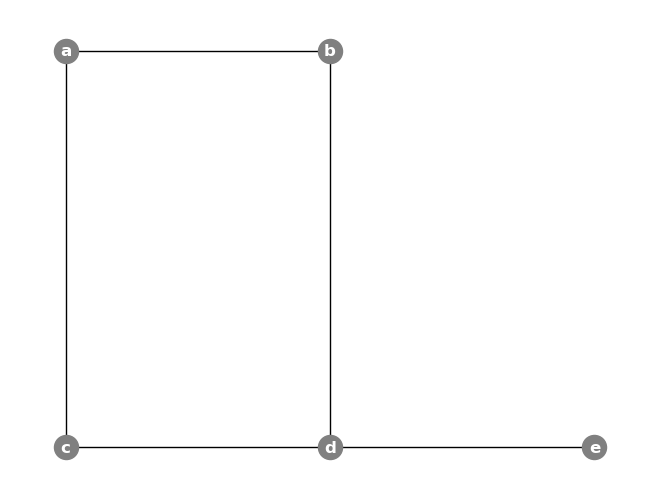

In [140]:
nx.draw(G, 
        pos=positions, 
        with_labels=True, 
        font_weight="bold", 
        font_color="white", 
        node_color="grey"
)

In [141]:
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G.edges.data()}

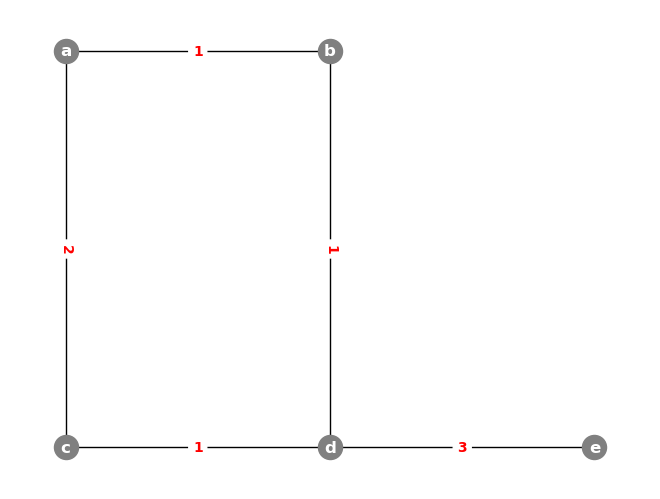

In [142]:
# Draw the graph
nx.draw(G, 
        pos=positions, 
        with_labels=True, 
        font_weight="bold", 
        font_color="white", 
        node_color="grey"
)

# Add edge labels
nx.draw_networkx_edge_labels(
    G, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

_**Figure 8.X.** A simple undirected graph consisting of five nodes and edges._

Although, you can easily add nodes and edges one at a time as shown previously, it is not typically very efficient way of construcing a graph. Luckily, `networkx` also allows you to pass the information for the graphs from a collection of items. Thus, we can create an identical graph as shown previously by passing a collection of nodes and edges to the graph as follows:

In [206]:
G2 = nx.Graph()

node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

edge_collection = [("a", "b", {"weight": 1}),
                   ("a", "c", {"weight": 2}),
                   ("b", "d", {"weight": 1}),
                   ("c", "d", {"weight": 1}),
                   ("d", "e", {"weight": 3}),
                  
                  ]

# Add nodes and edges from the collections
G2.add_nodes_from(node_collection)
G2.add_edges_from(edge_collection)

# Extract exact node locations
positions = {node: attrs["coords"] for node, attrs in G2.nodes.data()}

# Parse edge labels
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G2.edges.data()}

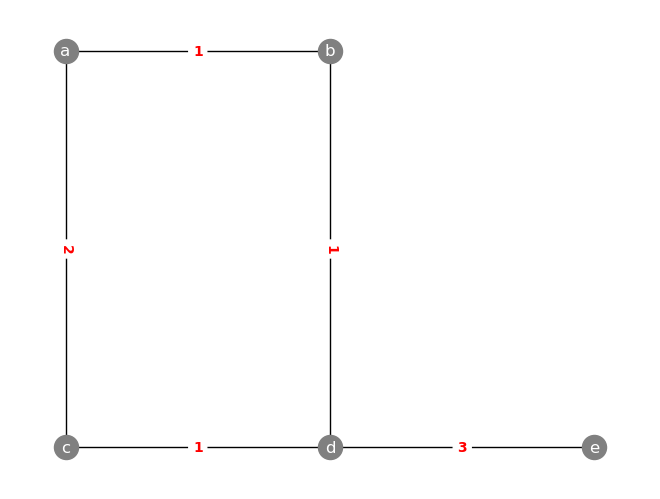

In [207]:
nx.draw(G2, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_edge_labels(
    G2, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

In [208]:
distance, path = nx.single_source_dijkstra(G=G2, 
                                          source="a",
                                          target="e", 
                                          weight="weight", 
                                          )

In [209]:
print("Distance:", distance)
print("Path / visited nodes:", path)

Distance: 5
Path / visited nodes: ['a', 'b', 'd', 'e']


In [210]:
distance, path = nx.single_source_dijkstra(G=G2, 
                                          source="e",
                                          target="a", 
                                          weight="weight", 
                                          )

In [211]:
print("Distance:", distance)
print("Path / visited nodes:", path)

Distance: 5
Path / visited nodes: ['e', 'd', 'b', 'a']


In [212]:
path_edges = list(zip(path,path[1:]))
path_edges

[('e', 'd'), ('d', 'b'), ('b', 'a')]

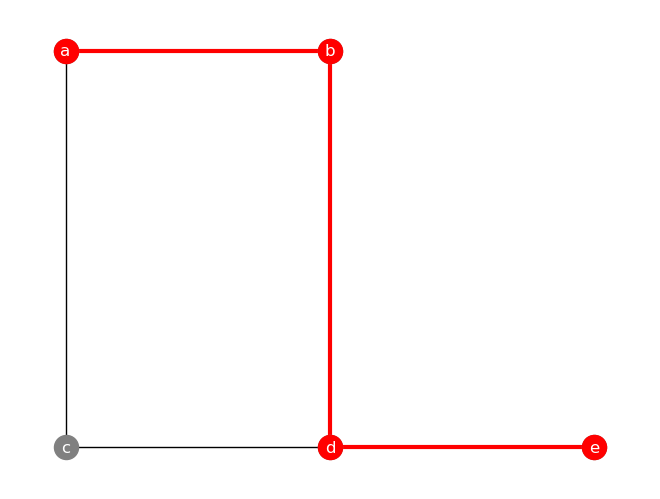

In [216]:
nx.draw(G2, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_nodes(G2, positions, nodelist=path, node_color='r')
nx.draw_networkx_edges(G2, positions, edgelist=path_edges, edge_color='r', width=3);

### Directed graph

In [173]:
G_directed = nx.MultiDiGraph()

In [174]:
node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

In [176]:
edge_collection = [("a", "b", {"weight": 1, "color": "red"}),
                   # bidirectional a<->c
                   ("a", "c", {"weight": 2, "color": "green"}),
                   ("c", "a", {"weight": 2, "color": "green"}),
                   # bidirectional b<->d
                   ("b", "d", {"weight": 1, "color": "green"}),
                   ("d", "b", {"weight": 1, "color": "green"}),
                   
                   ("c", "d", {"weight": 1, "color": "red"}),
                   ("d", "e", {"weight": 3, "color": "red"}),
                  ]

In [181]:
# Add nodes and edges from the collections
G_directed.add_nodes_from(node_collection)
G_directed.add_edges_from(edge_collection)

# Extract exact node locations
positions = {node: attrs["coords"] for node, attrs in G_directed.nodes.data()}

# Parse edge labels
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G_directed.edges.data()}

# Parse edge colors
edge_colors = [attrs["color"] for u, v, attrs in G_directed.edges.data()]

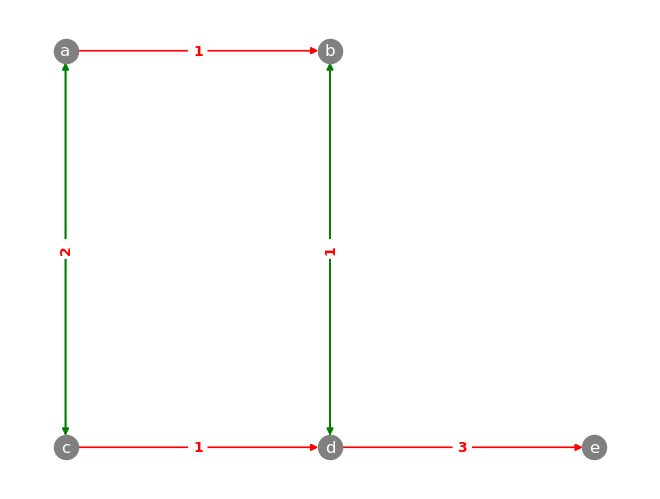

In [182]:
nx.draw(G_directed, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey",
        edge_color=edge_colors
       )

nx.draw_networkx_edge_labels(
    G_directed, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

In [218]:
distance, path = nx.single_source_dijkstra(G=G_directed, 
                                          source="a",
                                          target="e", 
                                          weight="weight", 
                                          )

In [219]:
path_edges = list(zip(path,path[1:]))
path_edges

[('a', 'b'), ('b', 'd'), ('d', 'e')]

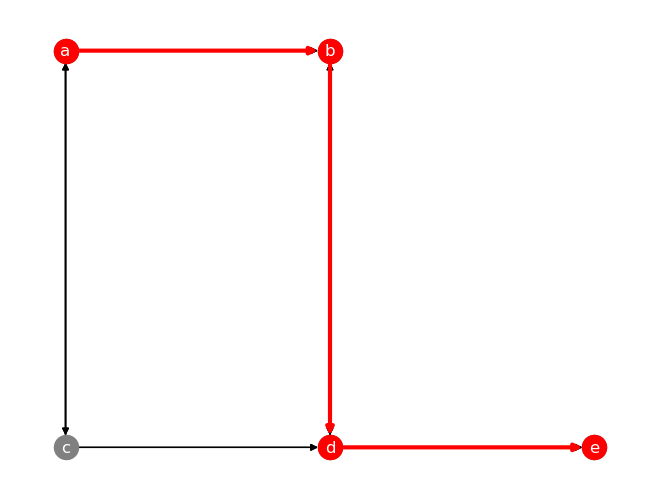

In [220]:
nx.draw(G_directed, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_nodes(G_directed, positions, nodelist=path, node_color='r')
nx.draw_networkx_edges(G_directed, positions, edgelist=path_edges, edge_color='r', width=3);

#### Question 8.1

What is the path length and route from `e` to `a` using the directed graph? 

In [ ]:
# You can use this cell to enter your solution.

In [223]:
# Solution

# This is a trick question: Because our graph is directed
# and there is no way out from node 'e', there is no path nor length
# from e to a

# When searching for such a path, networkx raises an error

# Uncomment to test yourself
# distance, path = nx.single_source_dijkstra(G=G_directed, source="e", target="a", weight="weight")

## Creating a graph from geometries

### Undirected graph using a GeoDataFrame

Data was obtained from Digiroad

In [343]:
import geopandas as gpd
import momepy
from contextily import add_basemap

In [344]:
fp = "data/digiroad_helsinki.gpkg"
streets = gpd.read_file(fp)
streets.head()

,id,direction,maxspeed,road_class,name,geometry
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385..."
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38..."
2,2,3,30,5,Kruunuvuorenkatu,"LINESTRING Z (387294.871 6671561.901 2.24, 387..."
3,3,2,30,5,Kristianinkatu,"LINESTRING Z (386646.115 6672721.35 16.528, 38..."
4,4,2,30,5,Fabianinkatu,"LINESTRING Z (386225.349 6671530.049 8.246, 38..."


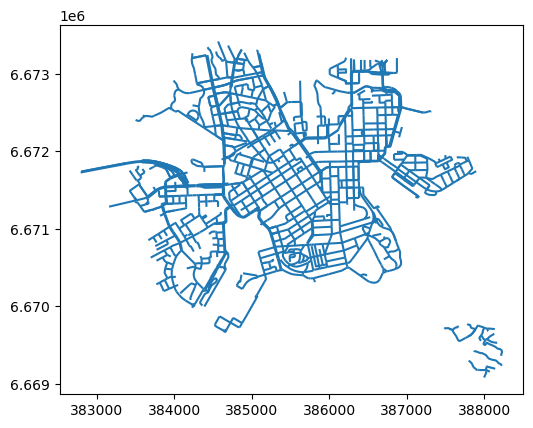

In [422]:
streets.plot();

In [457]:
def gdf_to_graph(gdf):
    """Creates a NetworkX Graph from GeoDataFrame consisting of LineString objects.

    Parameters
    ----------

    gdf : GeoDataFrame
        GeoDataFrame containing the LineString data.

    """

    # Create the NetworkX graph
    graph = nx.Graph()
        
    # Generate edge dictionary
    for edge in gdf.itertuples():
        coords = edge.geometry.coords

        # Get first and last node of the edge (excluding vertices)
        first, last = coords[0], coords[-1]

        # Edge attributes
        edge_attr = edge._asdict()

        graph.add_edge(first, last, **edge_attr)

    # Generate node attributes
    node_attrs = {node: {"coords": node, "x": node[0], "y": node[1]} for node in graph.nodes}
    nx.set_node_attributes(graph, node_attrs)  
    
    # Relabel the indices
    graph = nx.convert_node_labels_to_integers(graph)

    # Add some useful attributes    
    graph.graph['crs'] = gdf.crs

    return graph

Next we will break it down few steps at a time to understand what happens here. Let's start by investigating what happens inside the loop:

In [493]:
graph = nx.Graph()

for edge in streets.itertuples():
    # Get the coordinates
    coords = edge.geometry.coords

    # Get first and last node of the edge (excluding vertices)
    first, last = coords[0], coords[-1]

    # Get the edge attributes
    edge_attributes = edge._asdict()

    # Add to the graph
    graph.add_edge(first, last, **edge_attributes)
    break

Now we iterated over one edge in our street network and stopped the loop to be able to investigate what our variables contain. The `coords` variable contain the coordinates of all the vertices in the first edge of our street network:

In [498]:
list(coords)

[(385359.22199999995, 6671266.759999999, 8.729),
 (385388.0329999999, 6671288.834, 8.987),
 (385429.82200000004, 6671317.645999999, 8.732)]

As we can see, there are 3 vertices in this `LineString` object representing a given street. When constructing the graph topology, we only care about the `nodes` of the street segment geometry (i.e. the first and last coordinates of the geometry). This means that in case there are vertices between the nodes, those will not be taken into consideration in the topology of the graph (unless specifically needed for some special use case). Thus, the network topology itself does not need to have the full geometry of the street segments for it to work. 

<Axes: >

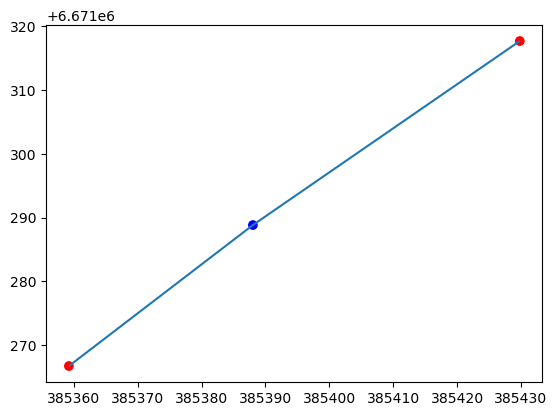

In [497]:
# Create a GeoDataFrame out of the vertices
vertices = gpd.GeoDataFrame(geometry=[Point(coordpair) for coordpair in coords])

fig, ax = plt.subplots()
streets.iloc[0:1].plot(ax=ax)
vertices.plot(ax=ax, color=["r", "b", "r"])

_**Figure 8.X.** Only the nodes (in red) will be used to construct the edge for a given network topology._

Considering only the nodes and ignoring the vertices has also benefits as doing this reduces the size of the graph and makes it faster to run any analyses on it. Thus, we only take the first and last coordinate-pair of the edge geometry which we will use as nodes:

In [499]:
print("First node:", first)
print("Last node:", last)

First node: (385359.22199999995, 6671266.759999999, 8.729)
Last node: (385429.82200000004, 6671317.645999999, 8.732)


Although the network topology only considers the nodes, this does not mean that you would loose the actual geometries of the street network, as we can still store the full geometry as an edge attribute of our graph. The `edge_attributes` variable contains all the associated information from the given row in our `GeoDataFrame` as a dictionary:

In [496]:
edge_attributes

{'Index': 0,
 'id': 0,
 'direction': 4,
 'maxspeed': 30,
 'road_class': 4,
 'name': 'Uudenmaankatu',
 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>}

When we call the `graph.add_edge(first, last, **edge_attributes)`, we add this edge to the given `graph` in which the `**edge_attributes` command unpacks the values of the dictionary and inserts them as attributes for the given edge. Thus, when we investigate the contents of the edges at this point in time, we will see that the actual `geometry` is also stored for the edge:

In [490]:
graph.edges.data()

EdgeDataView([((385359.22199999995, 6671266.759999999, 8.729), (385429.82200000004, 6671317.645999999, 8.732), {'Index': 0, 'id': 0, 'direction': 4, 'maxspeed': 30, 'road_class': 4, 'name': 'Uudenmaankatu', 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>})])

At this point, you might wonder what happened with the `nodes` as we did not specifically add them to the graph in a similar manner as in our earlier examples? We can investigate how the `nodes` look like at this stage:

In [491]:
graph.nodes.data()

NodeDataView({(385359.22199999995, 6671266.759999999, 8.729): {}, (385429.82200000004, 6671317.645999999, 8.732): {}})

As we can see, `networkx` actually adds the nodes automatically to the graph when we call the `.add_edge()` method based on the nodes provided to construct a given edge. However, as we can see from the nodes' data above, these nodes do not contain any information about the nodes in the nodes attributes as it is only an empty dictionary at this stage. This is something that we can handle afterwards as it is possible to set the node attributes also after the topology has been constructed based on the edges alone. To do this, we can e.g. parse the coordinates of the nodes and store that information as node attributes using the `nx.set_node_attributes()` as follows:

In [503]:
# Create a dictionary that contain the node attributes
node_attrs = {node: {"coords": node, "x": node[0], "y": node[1]} for node in graph.nodes}
nx.set_node_attributes(graph, node_attrs)  

In [504]:
graph.nodes.data()

NodeDataView({(385359.22199999995, 6671266.759999999, 8.729): {'coords': (385359.22199999995, 6671266.759999999, 8.729), 'x': 385359.22199999995, 'y': 6671266.759999999}, (385429.82200000004, 6671317.645999999, 8.732): {'coords': (385429.82200000004, 6671317.645999999, 8.732), 'x': 385429.82200000004, 'y': 6671317.645999999}})

As we can see, now the `nodes` of our graph includes three attributes that provide information about the location of the nodes: `coords`, `x` and `y`. 

Finally, you might have noticed that the `ids` for the nodes in our graph are quite cumbersome as they basically represent the exact coordinates of the nodes. Luckily, it is easy to relabel the node ids into a format that is easier to use and understand, using simple integer values as the ids. We can do this by using the `nx.convert_node_labels_to_integers()` function as follows:

In [505]:
graph = nx.convert_node_labels_to_integers(graph)

In [506]:
graph.edges.data()

EdgeDataView([(0, 1, {'Index': 0, 'id': 0, 'direction': 4, 'maxspeed': 30, 'road_class': 4, 'name': 'Uudenmaankatu', 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>})])

In [507]:
graph.nodes.data()

NodeDataView({0: {'coords': (385359.22199999995, 6671266.759999999, 8.729), 'x': 385359.22199999995, 'y': 6671266.759999999}, 1: {'coords': (385429.82200000004, 6671317.645999999, 8.732), 'x': 385429.82200000004, 'y': 6671317.645999999}})

As we can see, now the ids for the nodes were altered from long coordinate tuples into simple integers, such as `0` and `1`, which are much easier to understand and use if you e.g. want to select specific node from the graph. 

As a very last thing in our `gdf_to_graph()` function, we add a custom attribute to our graph where we store the coordinate reference system information of the input `GeoDataFrame` which can be useful information when using the given graph for analysis with other datasets:

In [509]:
graph.graph["crs"] = streets.crs
graph.graph["crs"]

<Projected CRS: EPSG:3067>
Name: EUREF-FIN / TM35FIN(E,N)
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Finland - onshore and offshore.
- bounds: (19.08, 58.84, 31.59, 70.09)
Coordinate Operation:
- name: TM35FIN
- method: Transverse Mercator
Datum: EUREF-FIN
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

That's it! This is how you can create an undirected graph based on a given `GeoDataFrame` that consists of `LineString` objects. The input data we used here represents streets, but the input data can basically be about anything as long as the geometries of the input data are represented as `LineString` objects and the data itself does have a network-like structure. In a similar manner, you could represent e.g. rivers, pipelines, power lines, social networks etc. 

Let's finally use our `gdf_to_graph()` function and create a full network topology based on our `streets` `GeoDataFrame`:

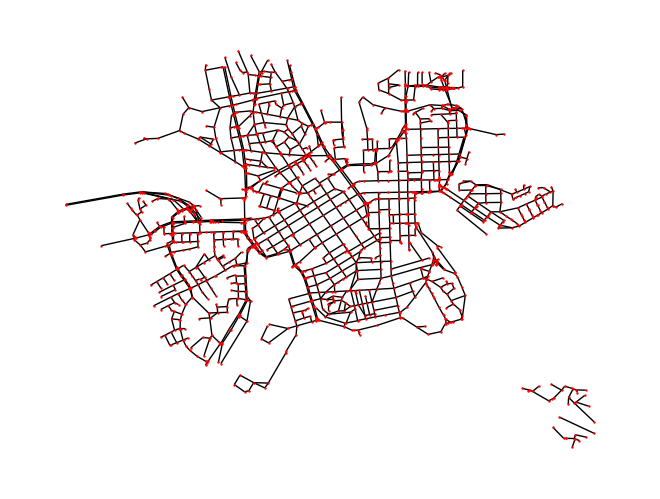

In [514]:
G = gdf_to_graph(streets)

positions = {node: (attrs["x"], attrs["y"]) for node, attrs in G.nodes.data()}

nx.draw(G, 
        pos=positions, 
        node_color="red",
        node_size=0.5,
       )

### Directed graph using a GeoDataFrame

Now as we have learned how to create a simple undirected graph based on `LineString` geometries, we will continue and expand the previous example to construct a directed graph topology that considers the permitted direction of movement along the streets. When working with street network data and analyzing e.g. the travel times or distances by car, it is necessary to take into consideration one-way streets as those are extremely common especially in larger cities. On these streets, a person can only drive to one direction, and if you would need to travel to opposite direction, making an U-turn is not possible but you would need to find another path using other streets of the network. Thus, understandingly one-way streets can have significant influence on the optimal routes between given locations that need to be considered when doing network analysis. Otherwise, our analyses and results will likely provide incorrect and unrealistic results that could even cause dangerous situations if e.g. a car navigator would guide you to a one-way street where the traffic flows against your travel direction. 

The `direction` column includes information about the allowed direction of the traffic flow, i.e. whether the traffic is permitted in both directions or whether it is a oneway street. In this street network dataset the values are coded as shown in Table 8.1.


: _**Table 8.1**. The rules for directed graph in terms of permitted direction of traffic._

| Value | Direction of traffic flow                                                             |
|-------|---------------------------------------------------------------------------------------|
| 2     | Traffic is permitted in both directions                                               |
| 3     | Traffic is permitted against the direction of digitalisation (end-node to start-node) |
| 4     | Traffic is permitted in the direction of digitalisation (start-node to end-node)      |

In [436]:
def gdf_to_directed_graph(gdf, direction='direction', both_ways=2, against=3, along=4):
    """Creates a NetworkX MultiDiGraph from road network GeoDataFrame.

    Parameters
    ----------

    gdf : GeoDataFrame
        GeoDataFrame containing the road network data.

    direction : str
        Name for column that contains information about the allowed driving directions

    both_ways : int
        Value specifying that the road is drivable to both directions.

    against : int
        Value specifying that the road is drivable against the digitizing direction.

    along : int
        Value specifying that the road is drivable along the digitizing direction.

    """

    # Create the NetworkX graph
    graph = nx.MultiDiGraph()
        
    # Generate edge dictionary
    for edge in gdf.itertuples():
        coords = edge.geometry.coords

        # Get first and last node of the edge (excluding vertices and possible Z coordinate)
        first, last = coords[0][:2], coords[-1][:2]

        # Edge attributes
        edge_attr = dict(edge._asdict())

        # Create edges according the direction rules
        if edge_attr[direction] == both_ways:

            # If road is bi-directional add it in both ways
            graph.add_edge(first, last, **edge_attr)
            graph.add_edge(last, first, **edge_attr)

        elif edge_attr[direction] == along:

            # Add the edge along digitization direction
            graph.add_edge(first, last, **edge_attr)

        elif edge_attr[direction] == against:
            
            # Add the edge against digitization direction
            graph.add_edge(last, first, **edge_attr)

    # Generate node attributes
    node_attrs = {node: {"coords": node, "x": node[0], "y": node[1]} for node in graph.nodes}
    nx.set_node_attributes(graph, node_attrs)  
    
    # Relabel the indices
    graph = nx.convert_node_labels_to_integers(graph)

    # Add some useful attributes    
    graph.graph['crs'] = gdf.crs

    return graph

In [439]:
G = gdf_to_directed_graph(streets)

In [440]:
positions = {node: attrs["coords"] for node, attrs in G.nodes.data()}

In [441]:
edge_colors = ["blue" if attrs["direction"] == 2 else "red" for u, v, attrs in G.edges.data()]

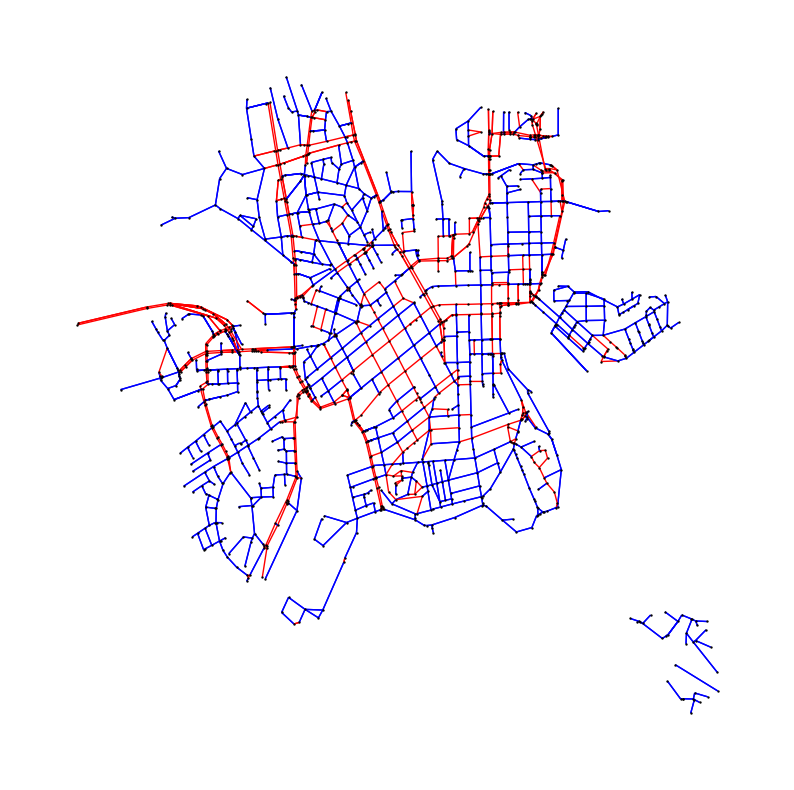

In [442]:
fig, ax = plt.subplots(figsize=(10,10))

nx.draw(G, 
        ax=ax,
        pos=positions, 
        node_color="black",
        node_size=0.5,
        edge_color=edge_colors,
        arrows=False,
       )

In [364]:
import osmnx as ox

In [431]:
nodes, edges = ox.graph_to_gdfs(G)

In [434]:
nodes.head()

,coords,x,y,geometry
osmid,,,,
0,"(385359.22199999995, 6671266.759999999)",385359.222,6671266.760,POINT (385359.222 6671266.76)
1,"(385429.82200000004, 6671317.645999999)",385429.822,6671317.646,POINT (385429.822 6671317.646)
2,"(386282.90299999993, 6672780.818)",386282.903,6672780.818,POINT (386282.903 6672780.818)
3,"(386282.4170000001, 6672754.728)",386282.417,6672754.728,POINT (386282.417 6672754.728)
4,"(387162.2939999999, 6671654.982999998)",387162.294,6671654.983,POINT (387162.294 6671654.983)


In [435]:
edges.head()

Index    id  direction  maxspeed  road_class              name  \
u v    key                                                                   
0 1    0        0     0          4        30           4     Uudenmaankatu   
1 140  0     1195  1201          4        30           4     Uudenmaankatu   
  1319 0     2335  2356          3        30           5      Albertinkatu   
2 3    0        1     1          3        40           4        Pitkäsilta   
3 1169 0     1196  1202          2        40           5  Kaisaniemenranta   

                                                     geometry  
u v    key                                                     
0 1    0    LINESTRING Z (385359.222 6671266.76 8.729, 385...  
1 140  0    LINESTRING Z (385429.822 6671317.646 8.732, 38...  
  1319 0    LINESTRING Z (385502.397 6671206.823 12.351, 3...  
2 3    0    LINESTRING Z (386282.417 6672754.728 4.562, 38...  
3 1169 0    LINESTRING Z (386282.417 6672754.728 4.562, 38...

As many Python libraries related to working with have been 

In [342]:
import neatnet

streets_cleaned = neatnet.remove_interstitial_nodes(streets)
streets_cleaned.shape

(2179, 7)

In [443]:
net = ox.graph_from_place(query=["Helsinki", "Espoo"])

In [444]:
edges = ox.graph_to_gdfs(net, nodes=False)

<Axes: >

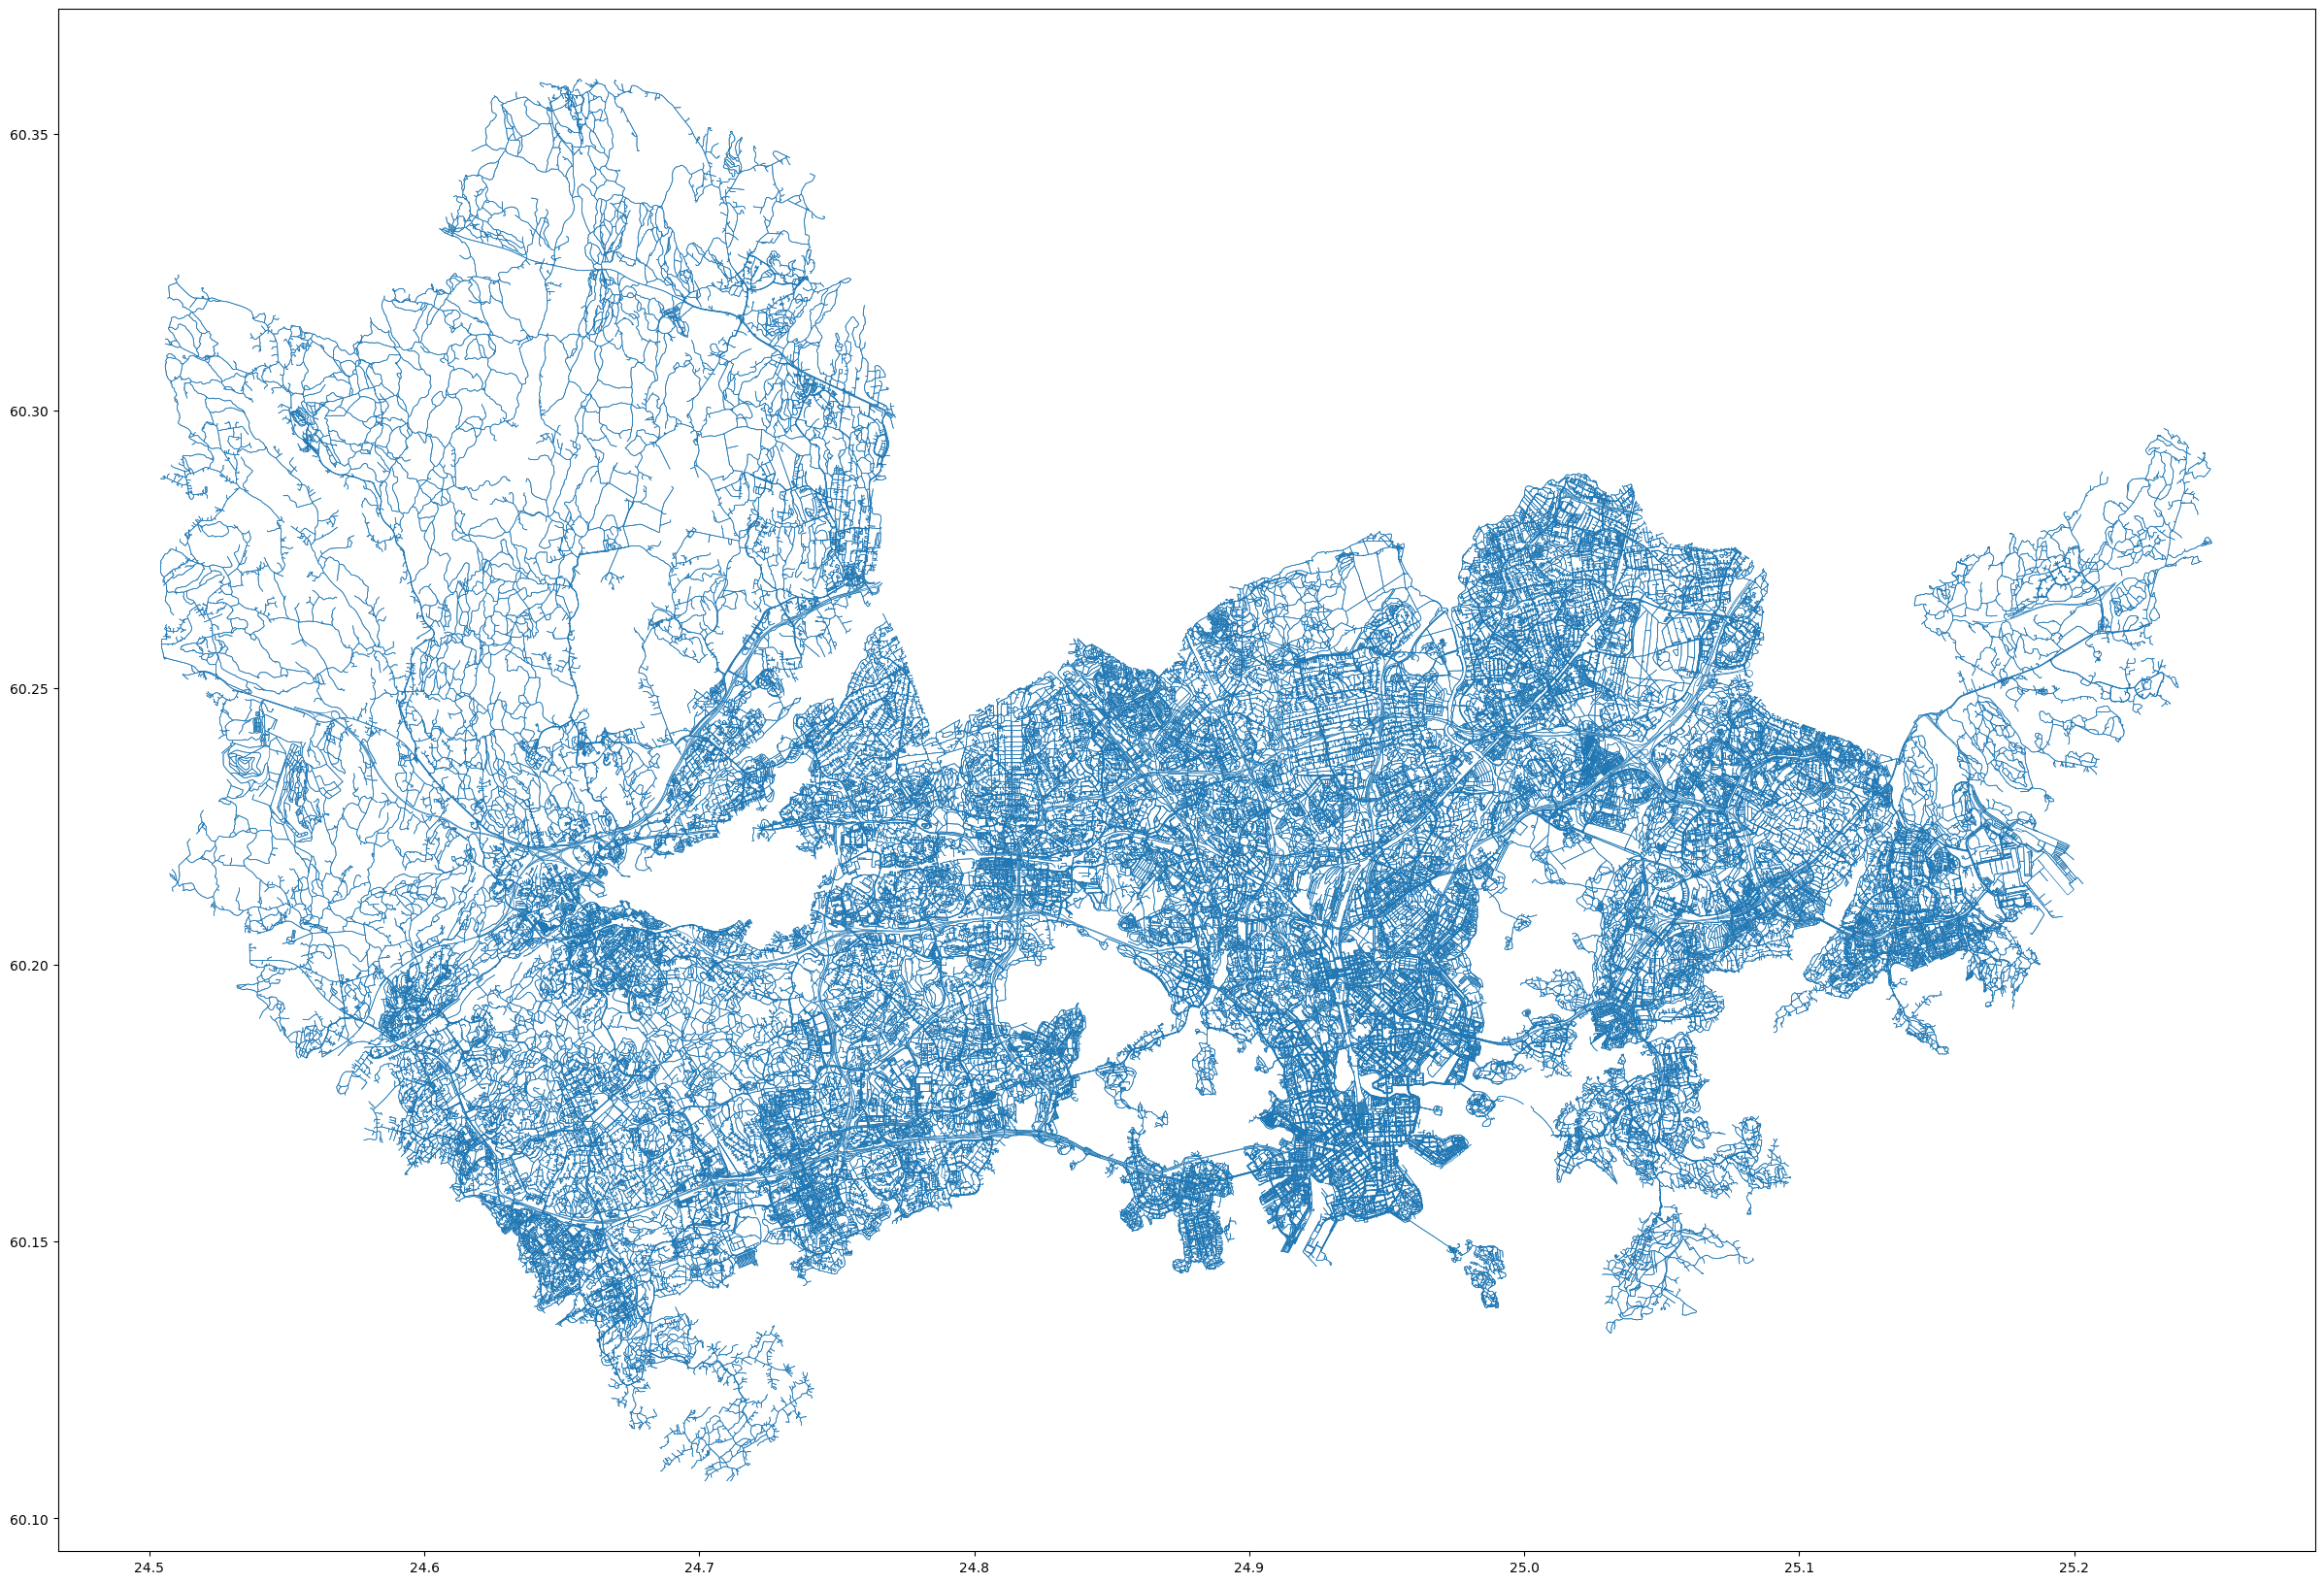

In [447]:
edges.plot(figsize=(30,30), linewidth=0.5)